# Weekly Project (Beginner Level): Heart Disease Prediction

**Goal:** Build a simple machine learning model that predicts whether a patient has heart disease, using basic clinical data.

**Dataset:** UCI Heart Disease dataset (303 patients, 13 features, target = 1 if disease present, 0 if not).


## Step 1: Import Libraries

We only need a few basic libraries: pandas for data handling, matplotlib/seaborn for charts, and scikit-learn for machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

## Step 2: Load the Dataset

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (303, 14)


**What do the columns mean?**

- `age`, `sex` — basic patient info (sex: 1 = male, 0 = female)
- `cp` — chest pain type
- `trestbps` — resting blood pressure
- `chol` — cholesterol level
- `fbs` — fasting blood sugar (1 = high)
- `restecg` — resting ECG result
- `thalach` — maximum heart rate achieved
- `exang` — exercise-induced chest pain (1 = yes)
- `oldpeak`, `slope` — ST segment measurements from exercise test
- `ca` — number of major blood vessels visible on scan
- `thal` — thalassemia test result
- `target` — 1 = has heart disease, 0 = no heart disease (this is what we want to predict)

## Step 3: Basic Data Check

Before building a model, we always check the data is clean — no missing values, no weird types.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


There are no missing values, so we don't need to fill or drop anything.

## Step 4: Simple Exploration (EDA)

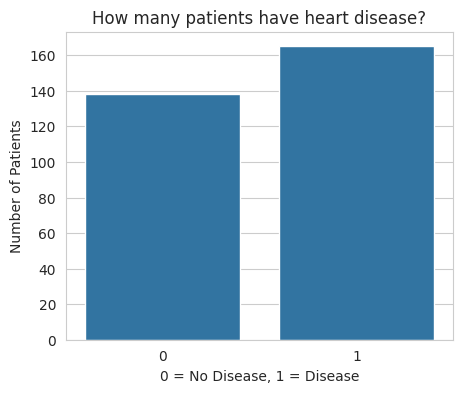

target
1    165
0    138
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title('How many patients have heart disease?')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Number of Patients')
plt.show()

print(df['target'].value_counts())

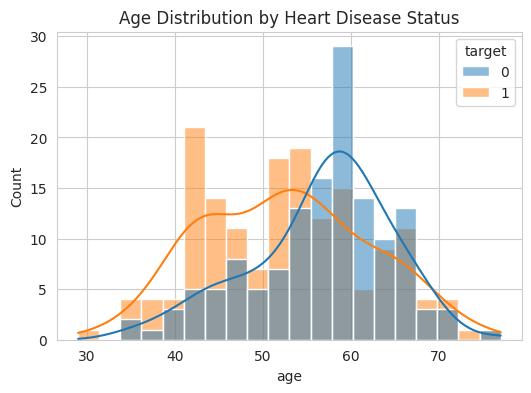

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True)
plt.title('Age Distribution by Heart Disease Status')
plt.show()

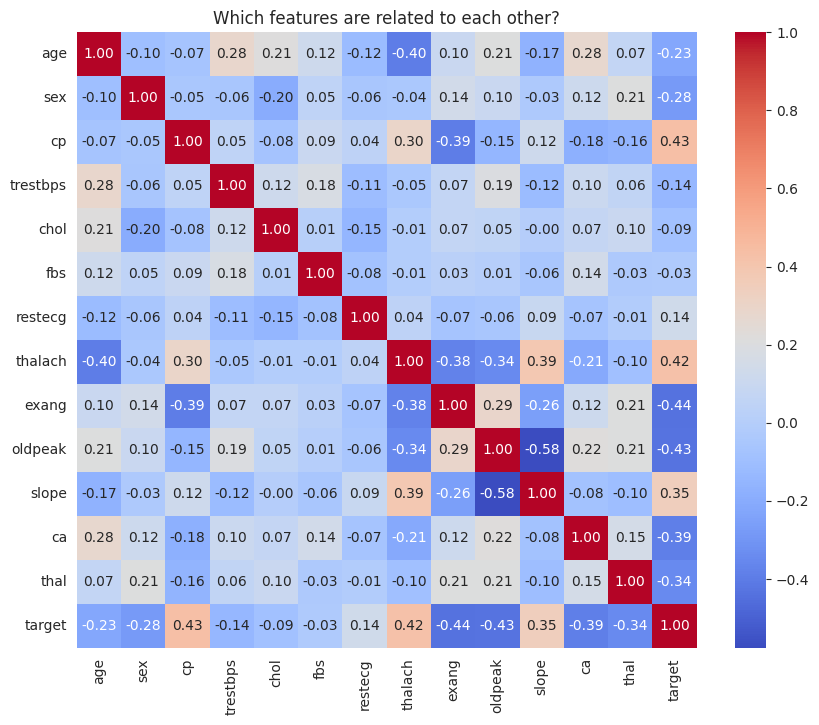

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Which features are related to each other?')
plt.show()

## Step 5: Prepare the Data for Machine Learning

We separate the data into:
- `X` = the input features (everything except `target`)
- `y` = the answer we want to predict (`target`)

Then we split into a **training set** (used to teach the model) and a **test set** (used to check how well it learned, on data it hasn't seen).

In [9]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


We also scale the features so they're all on a similar range (important for models like KNN and Logistic Regression).

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 6: Try a Few Simple Models

As beginners, it's good practice to try more than one simple algorithm and see which one fits our data best, instead of guessing.

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
}

scores = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    scores[name] = acc
    print(f"{name}: {acc:.3f} accuracy")

Logistic Regression: 0.852 accuracy
K-Nearest Neighbors: 0.902 accuracy
Decision Tree: 0.754 accuracy


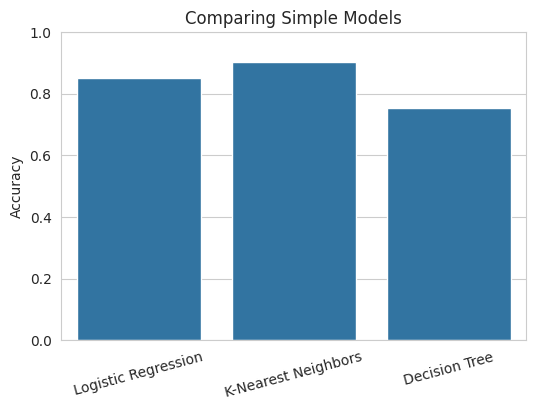

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(scores.keys()), y=list(scores.values()))
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Comparing Simple Models')
plt.xticks(rotation=15)
plt.show()

## Step 7: Pick the Best-Fitting Model

We automatically pick whichever model scored the highest accuracy above, and look at it more closely.

In [13]:
best_name = max(scores, key=scores.get)
best_model = models[best_name]

print("Best model for this dataset:", best_name)
print("Accuracy:", round(scores[best_name], 3))

Best model for this dataset: K-Nearest Neighbors
Accuracy: 0.902


In [14]:
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.87      0.93      0.90        29
     Disease       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



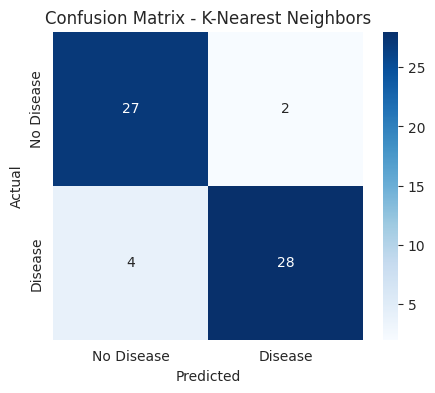

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

**How to read the confusion matrix:**
- Top-left: patients correctly predicted as "No Disease"
- Bottom-right: patients correctly predicted as "Disease"
- Top-right & bottom-left: mistakes the model made

## Step 8: Try It on a New Patient (Example)

Let's simulate predicting on one new, made-up patient to see how the model would be used in practice.

In [16]:
# Example patient data (values follow the same column order as X)
new_patient = pd.DataFrame([{
    'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 130, 'chol': 246,
    'fbs': 0, 'restecg': 1, 'thalach': 150, 'exang': 0,
    'oldpeak': 1.2, 'slope': 1, 'ca': 0, 'thal': 2
}])

new_patient_scaled = scaler.transform(new_patient)
prediction = best_model.predict(new_patient_scaled)[0]

print("Prediction:", "Heart Disease Likely" if prediction == 1 else "No Heart Disease Likely")

Prediction: Heart Disease Likely


## Summary

- We loaded the UCI Heart Disease dataset (303 patients, 13 features) and confirmed it had no missing values.
- We explored the data with simple charts: target balance, age distribution, and a correlation heatmap.
- We split the data into training and test sets, and scaled the features.
- We trained three beginner-friendly models — Logistic Regression, KNN, and Decision Tree — and compared their accuracy.
- We automatically selected whichever model performed best on this dataset and evaluated it with a classification report and confusion matrix.
- Finally, we showed how the trained model can be used to predict on a brand-new patient.
